In [11]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

## Exploratory Data Analysis

The goal is to demonstrate that it's reasonable to investigate how sensitive MADDPG is to hyperparameters (and environment parameters). That is, under what conditions does it fail to learn swarm behavior?

Some plots we can use are:
- histogram of average rewards
- box plot of rewards and/or DoS/DoA
- scatter plot of average reward, DoS, DoA

A really easy argument to make is: we see good learning behavior in one random seed, but not another.

We can also hypothesize when it may break depending on the "weaknesses" of MADDPG.

In [12]:
def load_data(file_path, print_info=True):
    data = pl.read_csv(file_path)
    if print_info:
        print(data.glimpse())
    return data


def plot_dos_and_doa(data: pl.DataFrame, window_size=10):
    """
    Plot DoS and DoA metrics with moving average and standard deviation bands.
    
    Args:
        data: Polars DataFrame containing the metrics
        window_size: Window size for moving average calculation
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes = axes.flatten()
    
    # Get the episode and metric columns
    episode = data['# episode'].to_numpy()
    
    # Plot DoS
    if 'dos' in data.columns:
        dos = data['dos'].to_numpy()
        dos_ma = np.convolve(dos, np.ones(window_size)/window_size, mode='valid')
        dos_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        dos_std = np.array([dos[max(0, i-window_size):i].std() for i in range(window_size, len(dos)+1)])
        
        axes[0].plot(dos_episodes, dos_ma, 'b-', linewidth=2, label='Moving Average')
        axes[0].fill_between(dos_episodes, dos_ma - dos_std, dos_ma + dos_std, 
                            alpha=0.3, color='blue', label='±1 Std Dev')
        axes[0].scatter(episode, dos, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylabel('DoS')
        axes[0].set_title('Degree of Swarming (DoS)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Plot DoA
    if 'doa' in data.columns:
        doa = data['doa'].to_numpy()
        doa_ma = np.convolve(doa, np.ones(window_size)/window_size, mode='valid')
        doa_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        doa_std = np.array([doa[max(0, i-window_size):i].std() for i in range(window_size, len(doa)+1)])
        
        axes[1].plot(doa_episodes, doa_ma, 'r-', linewidth=2, label='Moving Average')
        axes[1].fill_between(doa_episodes, doa_ma - doa_std, doa_ma + doa_std, 
                            alpha=0.3, color='red', label='±1 Std Dev')
        axes[1].scatter(episode, doa, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[1].set_xlabel('Episode')
        axes[1].set_ylabel('DoA')
        axes[1].set_title('Degree of Alignment (DoA)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## DDPG

Rows: 200
Columns: 3
$ # episode <f64> 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0
$ dos       <f64> 11.575307, 10.723861, 8.236722, 7.956298, 7.78834, 7.261917, 5.819388, 6.682804, 7.657137, 6.507325
$ doa       <f64> 11.934388, 14.023124, 14.431037, 16.413301, 15.866328, 15.732698, 15.806853, 16.558115, 11.260074, 20.821092

None


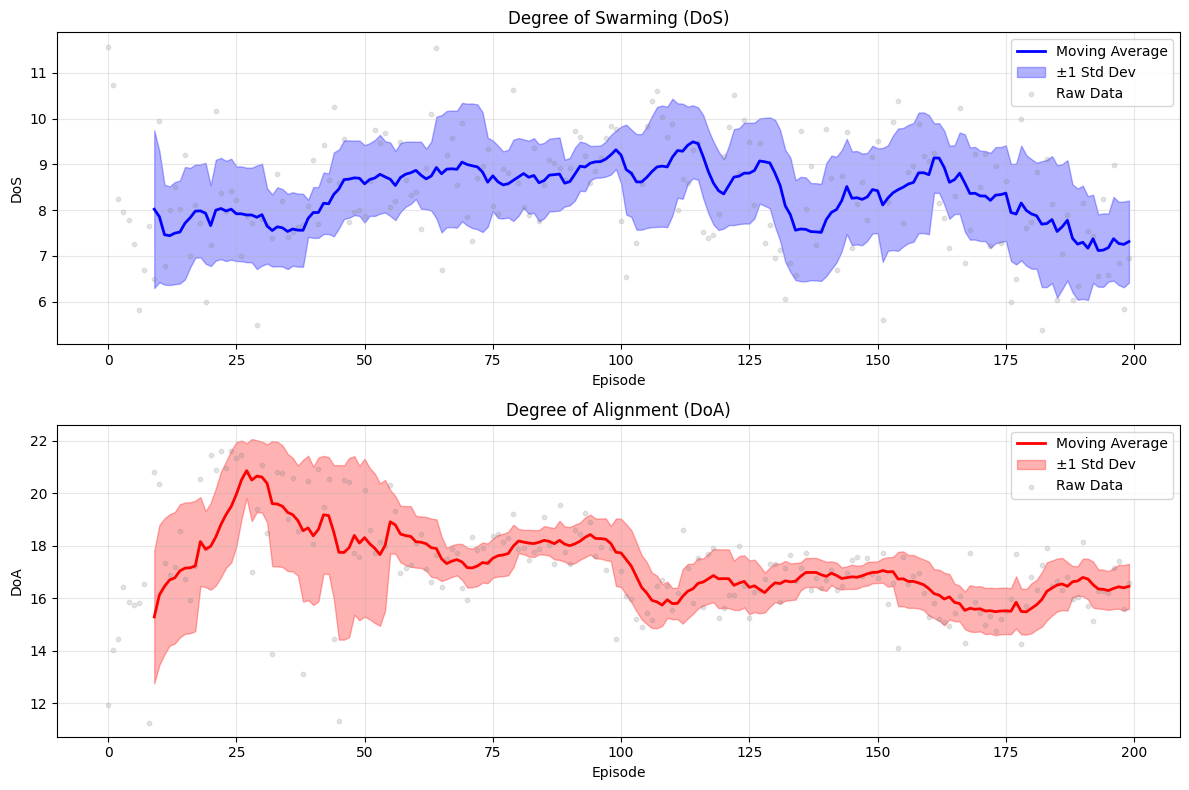

In [13]:
file_path = '../experimental_methods/models/ddpg/run1/metrics.csv'

ddpg_data = load_data(file_path)
plot_dos_and_doa(ddpg_data)


## MADDPG

Rows: 200
Columns: 14
$ # episode <f64> 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0
$ dos       <f64> 11.277767, 9.651666, 9.173544, 9.385518, 8.61497, 6.722814, 10.66565, 9.923331, 11.611331, 11.405271
$ doa       <f64> 10.666923, 17.914734, 19.860282, 14.57382, 17.389801, 18.221901, 19.500971, 16.118984, 15.593498, 10.883522
$ reward_0  <f64> 0.208786, 0.177033, 0.066859, -0.011454, 0.467462, 0.549074, -0.014013, 0.013171, 0.345529, 0.329057
$ reward_1  <f64> -0.01908, -0.01208, -0.011048, -0.016011, -0.012232, -0.015334, -0.015381, -0.020509, -0.042199, -0.026124
$ reward_2  <f64> -0.011143, -0.011901, -0.012049, -0.021181, -0.012811, -0.016304, -0.017708, -0.022023, -0.030887, -0.047958
$ reward_3  <f64> -0.010711, -0.027317, -0.019885, -0.02094, -0.012332, -0.015575, -0.015639, -0.02043, -0.023786, -0.028144
$ reward_4  <f64> -0.011314, -0.019325, -0.011511, -0.017446, -0.012145, -0.013942, -0.014693, -0.019573, -0.03325, -0.029791
$ reward_5  <f64> -0.010881, -0.015316, -0.0

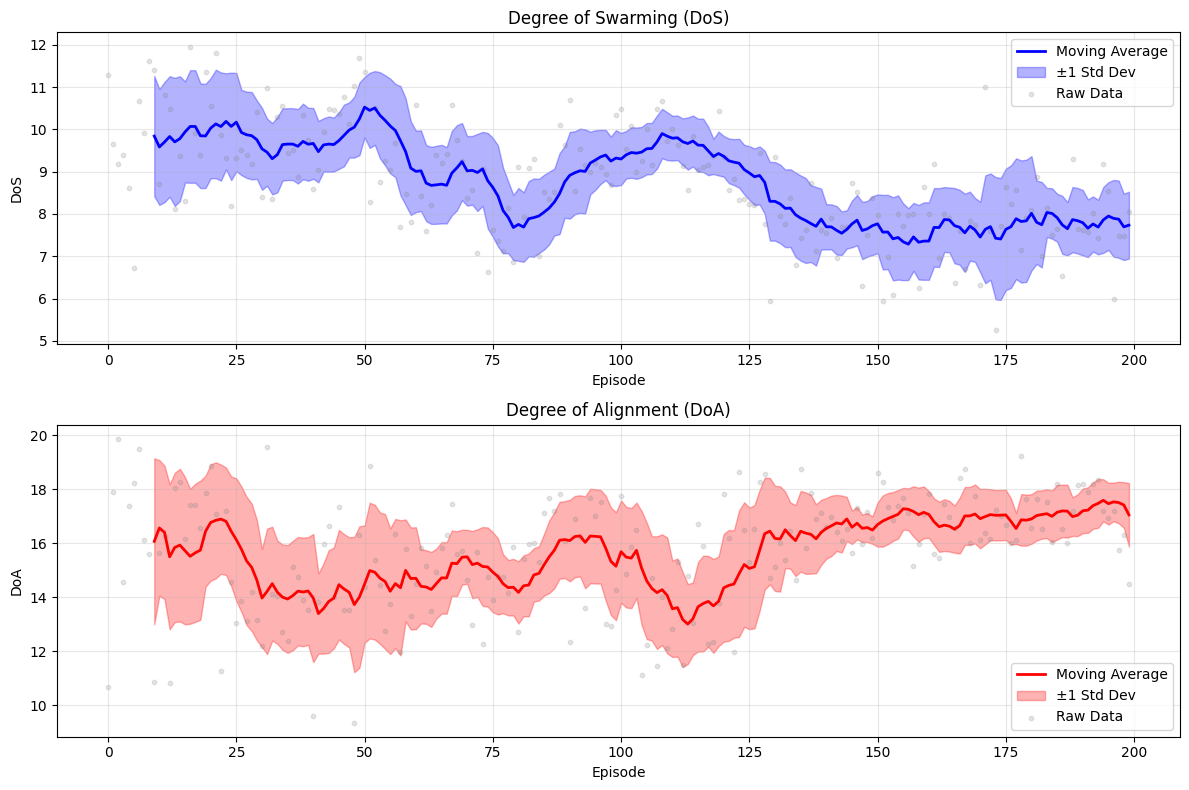

In [14]:
file_path2 = '../experimental_methods/models/maddpg/run33/metrics.csv'

maddpg_data = load_data(file_path2)
plot_dos_and_doa(maddpg_data)

Rows: 201
Columns: 3
$ # episode <f64> 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0
$ dos       <f64> 5.91367, 5.351831, 4.67564, 2.848705, 6.198427, 6.300598, 5.254088, 3.796103, 6.16637, 5.939177
$ doa       <f64> 7.73505, 7.140152, 8.017862, 7.751127, 6.996925, 6.499031, 7.657446, 8.680181, 8.791124, 10.462318

None


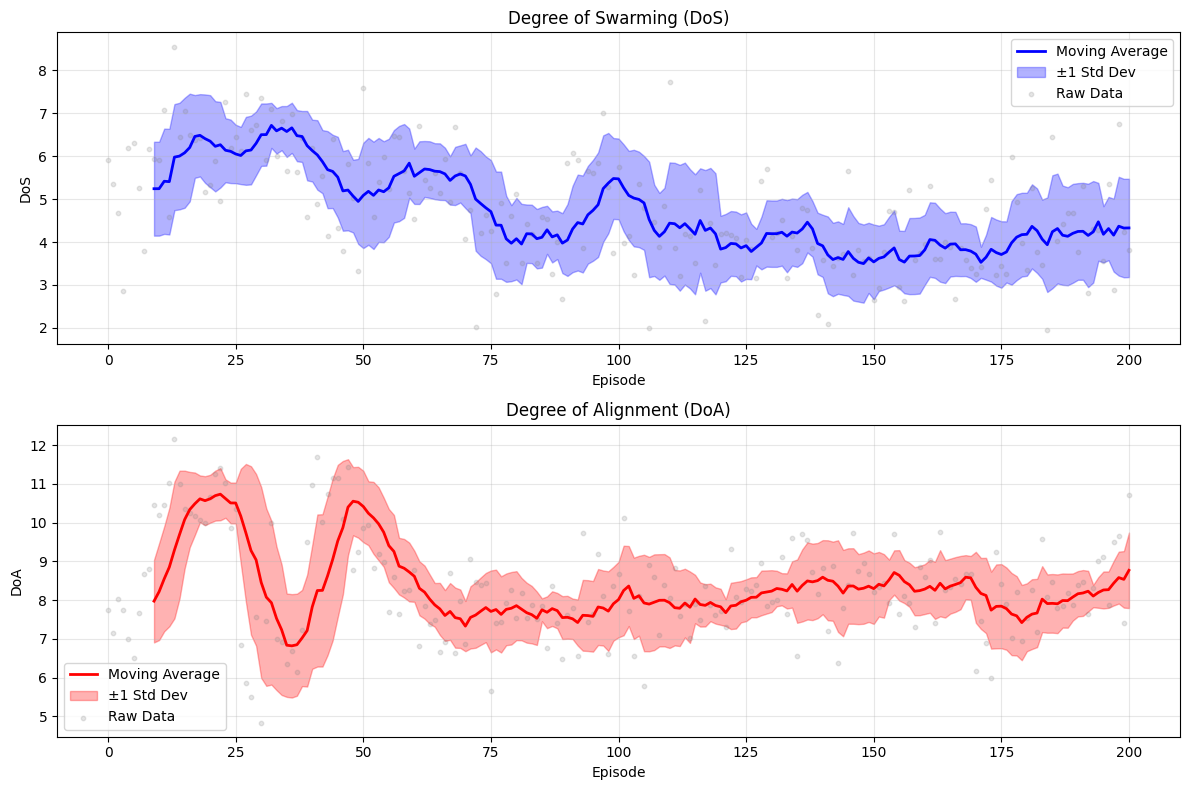

In [15]:
file_path3 = '../experimental_methods/models/maddpg/run6/metrics.csv'

maddpg_data2 = load_data(file_path3)
plot_dos_and_doa(maddpg_data2)